# Soft Cache

The concept is here

## Problem Description

We have an amplifiying device that takes time to start amplifying. The output power builds and builds until it reaches steady-state. We have to calculate the average power and spectrum of a signal during steady-state. The startup time changes from run to run, so we have to calculate the startup time beofore calculating power and the spectrum. We need the startup time for both methods and we want each method to be self-sufficient. First lets generate the data

## Data Generation

We generate one datapoint in the following code. The `sineStep()` function is just a step function that goes from 0 to 1 smoothly using a squared sine function. The `np.maximum` and `np.minimum` functions blah... The `sineStep()` function  is used to generate the *envelope* of the output voltage, also known as amplitude.  And the output power is the voltage squared over the the impedance, V^2/Z.

In [12]:
import pandas as pd
import numpy as np
import shutil
import os
from pathlib import Path

def sineStep(t,risetime):
    return np.sin(0.5*np.pi*np.maximum(0.0,np.minimum(1.0,t/risetime)))**2

# waveform parameters
freq =                 1e3             # frequency
T = 1/freq                             # Period
t = np.linspace(0,50*T,1000)  # time vector, 10 periods

risetime = 10*T               # takes 10 periods to rise to steady-state
delay = 10/freq*2
gain = 20

A = 1+(gain-1)*sineStep(t-delay,risetime)
V = A*np.sin(2*np.pi*freq*t)
Z = 1.0            # Impedance  
P = V**2/Z         # output power

We plot the voltage and power below.

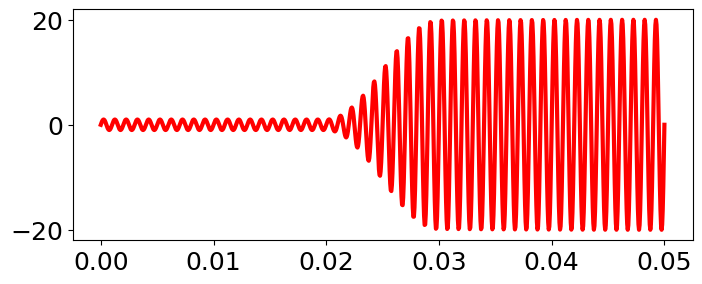

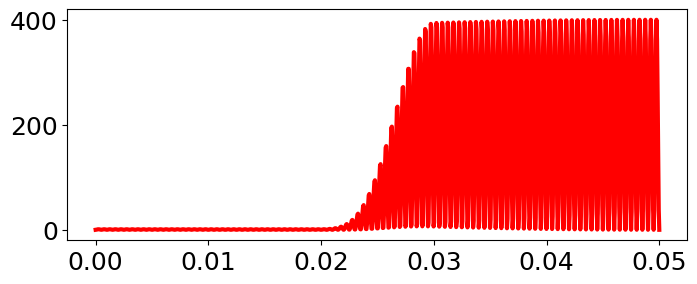

In [13]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(8,3))
ax = fig.subplots(nrows=1,ncols=1)
ax.plot(t,V)

fig = plt.figure(2, figsize=(8,3))
ax = fig.subplots(nrows=1,ncols=1)
ax.plot(t,P)

**__For Electrical Engineers__** The voltage goes from positive to negative and the frequency is 1 kHz.The power is only positive and the frequency is doubled. This is typical for linear devices like resistors in circuits. 

**__For Everybody__** The power takes around 0.02 seconds to start ramping up, and reaches steady state at around 0.03 seconds.

We want to take the average power and calculate get the spectrum after steady state for many data points. Below is code to generate multiple datapoints and save the data to the disk.

In [14]:
from dmanage.metadata.metastring import compose
def generate_data(saveloc):
    """Generate example data for the project
    This generates 10 csv files with time and voltage columns. Each file is
    tagged with a metastring, the input voltage is labeled in the filename
    
    Parameters
    ----------
    saveLoc : string
        path to save the data.
    """
    
    # waveform parameters
    f = np.array([1e3,2e3])                      # frequency
    T = 1/f                       # Period
    t = np.linspace(0,50*max(T),10000)  # time vector, 10 periods
    N = 20  # number of data units
    # delete the contents of the folder if it exists
    if os.path.exists(saveloc):
        shutil.rmtree(saveloc)  # this command fails if directory doesnt exist
    # create the save directory if it doesn't exist
    if not os.path.exists(saveloc):
        os.makedirs(saveloc)    # this command fails if the directory exists already
        
    freqs = np.linspace(f[0],f[1],N)
    for freq in freqs:
        risetime = 10*T[0]
        delay = 10/freq*2
        gain = 20
        A = 1+(gain-1)*sineStep(t-delay,risetime)
        power = A*np.sin(2*np.pi*freq*t)**2       # output power
        # save waveform
        savetag = compose({'freq':'%0.2fe3'%(freq/1e3)})
        savename = 'waveform_%s.csv'%savetag   
        data = np.stack([t,power]).T  
        waveform = pd.DataFrame(data,columns=['Time','Power'])   # create pandas dataframe
        waveform.to_csv(saveloc+savename,index=False)            # save to a file
datapath = './data/'
generate_data(datapath)

This code saves multiple files in the `./data/` directory. The frequency and the steady state power are different for each datapoint. 

**__NOTE:__** we utilize the `dmanage.metadata.metastring.compose` method to generate the metastrings that give each file a unique filename that describes the frequency associated with that data. See metastrings for more information.

The data looks like.

```console
$ tree
.
├── waveform_freq-1.00e3.csv
├── waveform_freq-1.05e3.csv
├── waveform_freq-1.11e3.csv
├── waveform_freq-1.16e3.csv
├── waveform_freq-1.21e3.csv
├── waveform_freq-1.26e3.csv
├── waveform_freq-1.32e3.csv
├── waveform_freq-1.37e3.csv
├── waveform_freq-1.42e3.csv
├── waveform_freq-1.47e3.csv
├── waveform_freq-1.53e3.csv
├── waveform_freq-1.58e3.csv
├── waveform_freq-1.63e3.csv
├── waveform_freq-1.68e3.csv
├── waveform_freq-1.74e3.csv
├── waveform_freq-1.79e3.csv
├── waveform_freq-1.84e3.csv
├── waveform_freq-1.89e3.csv
├── waveform_freq-1.95e3.csv
└── waveform_freq-2.00e3.csv
```

Now we process this data using dmanage.

## Processing the Data

Below we directly use the D-Manage methodology to process the data both with and without a soft cache. 

### Without Soft Cache

Our DataUnit class is defined below. In addition to the `__int__()` and `is_valid()` methods required by the data hierarchy, we have 5 functions to do everything we need:

* `read_waveform()`: read the power signal
* `get_startup()`: get the startup time using the `dmanage.dfmethods.signal.get_startup` method from `dmanage`. 
* `get_avg()`: Get the average steady-state power
* `get_freq()`: Get the average steady-state frequency
* `get_summmary()`: summarizes the relevant data in a pandas Series: the data path,startup time, steady-state power, and frequency

Our DataGroup class created using the data hierarchy methodology.link ???

In [15]:
# necessary packages for data hierarchy
from dmanage.group import make_data_group
from dmanage.unit import make_data_unit
from dmanage.decorate import override
from dmanage.metadata.metastring import compose,parse
import dmanage.dfmethods as dfm

DataUnit = make_data_unit()
class MyDataUnit(DataUnit):
    def __init__(self,filepath):
        """open the data unit
        """
        self.dataUnit = filepath
        self.baseDir = os.path.join(os.path.dirname(filepath),'')
        self.wavename = 'power'
        
    def is_valid(self,dataUnit):
        """returns bool if the file is a valid data file. 
        The '.csv' extension test could be more robust.
        """
        return ('.csv' in dataUnit)
    
    def read_waveform(self):
        df = pd.read_csv(self.dataUnit)
        df = df.set_index('Time')
        return df
        
    @override()
    def get_startup(self,):
        df = self.read_waveform()
        tStart = dfm.signal.get_startup(df,cutoff=[1e2, 5e4])
        return tStart
    
    @override()
    def get_avg(self):
        tStart = self.get_startup()
        df = self.read_waveform()
        df = df.loc[df.index.get_level_values(0)>tStart]
        avg = df.mean().to_numpy()[0]
        return avg
    
    @override()
    def get_freq(self):
        tStart = self.get_startup()
        df = self.read_waveform()
        df = df.loc[df.index.get_level_values(0)>tStart]
        fft = dfm.fft.fft(df)
        A = dfm.fft.fft_amplitude(fft)
        freq = A.idxmax().iloc[0]
        if isinstance(freq,tuple):
            # MultiIndex is a tuple, even if it only has one level
            # Index would not be a tuple and would cause an error
            freq = freq[0]
        return freq

    @override()
    def get_summary(self):
        # this can utilize the cacheing in DataGroup implementation
        summary = {}
        summary['file'] = self.dataUnit
        summary['tStart'] = self.get_startup()
        summary['Pavg'] = self.get_avg()
        summary['freq'] = self.get_freq()
        # we use series here because key, value pairs correspond to index value pairs
        df = pd.Series(summary)  
        return df


DataGroup = make_data_group(MyDataUnit)
class MyDataGroup(DataGroup):
    pass

Note that `get_startup()`, `get_avg()`, and `get_freq()` all need to read the waveform, and `get_avg()` and `get_freq()` need to calculate the startup. This is inefficient! Let's time the execution of the entire data group.

In [16]:
import time
# call the functions here and time it
DG = MyDataGroup(datapath,dataUnitType='file')
startTime = time.time()
summary = DG.get_summary()
summary = pd.concat(summary,axis=1).T
executionTime = time.time() - startTime
print('Execution without SoftCache: %f seconds'%executionTime)
print(summary)

Opening ./data/... Done in 0.001 Seconds
Execution without SoftCache: 0.844788 seconds
                               file    tStart       Pavg         freq
0   ./data/waveform_freq-1.00e3.csv  0.026753   9.887851  1978.722306
1   ./data/waveform_freq-1.05e3.csv  0.024937   9.776733   2114.71269
2   ./data/waveform_freq-1.11e3.csv  0.024657   9.885927  2209.723757
3   ./data/waveform_freq-1.16e3.csv  0.023967   9.921469  2304.802151
4   ./data/waveform_freq-1.21e3.csv  0.022922   9.864822  2437.429363
5   ./data/waveform_freq-1.26e3.csv  0.022762   9.898625  2533.251331
6   ./data/waveform_freq-1.32e3.csv  0.021472   9.877304  2629.009641
7   ./data/waveform_freq-1.37e3.csv  0.022107   9.972885  2724.718537
8   ./data/waveform_freq-1.42e3.csv  0.019882   9.811823  2855.434169
9   ./data/waveform_freq-1.47e3.csv  0.021547   9.962714  2952.253076
10  ./data/waveform_freq-1.53e3.csv  0.018512   9.795428  3048.766079
11  ./data/waveform_freq-1.58e3.csv  0.021057   9.998466  3144.122322
12 

It takes almost half a second to generate a summary. Now let's define the soft cache and minimize redundant operations. 

### With Soft Cache

Here we define our SoftCache class that will be a component of the DataUnit.

In [17]:
class SoftCache(dict):
    """This class is a modified dictionary class
    """
    def __getattr__(self, key):
        """This is overrides the attribute get method to get the dictionary values
        """
        if not key in self.keys():
            raise AttributeError("No '%s' in cache"%(key))
        return self[key]
    
    def __setattr__(self, key, value):
        """This is overrides the attribute set method to set the dictionary values
        """
        self[key] = value

    def __getitem__(self, key : str):
        """This is the dictionary method to get values from keys
        """
        if (not key in self.keys() and key[0] != '_'):
            raise KeyError("No '%s' in cache"%(key))
        return super().__getitem__(key)
   
    def __setitem__(self, key : str, value : all):
        """This is the dictionary method to set values from keys
        """
        return super().__setitem__(key, value)

    def get(self,key,method=None,*args,**kwargs):
        """this method gets the cahed value if it exists, or calls the method to set the cached value.
        """
        if (not key in self.keys()) and (method is not None):
            self[key] = method(*args, **kwargs)
        return self[key]




The `SoftCache` class is derived from the dictionary class in Python. The SoftCache can use dictionary syntax or attribute syntax to get and set values. Here are the ways to set and get values from the class. 


In [18]:
cache = SoftCache()
# dict item set and get
cache['key'] = 'value'
print("cache['key'] -> %s"%(cache['key']))
print('cache.key -> %s'%(cache.key))        # identical to 'cache['key']'

# attribute set and get
cache.attribute = 'another value'
print('cache.attribute -> %s'%(cache.attribute))
print("cache['attribute'] -> %s"%(cache['attribute']))  # identical to 'cache.attribute'
print('SoftCache looks like a dictionary:\n %s'%cache)


cache['key'] -> value
cache.key -> value
cache.attribute -> another value
cache['attribute'] -> another value
SoftCache looks like a dictionary:
 {'key': 'value', 'attribute': 'another value'}


The most useful method in the `SoftCache` class is the `get()` method. It gets cached values if they exist, and if they don't exist it calls the method and following args and kwargs on the input to set the cached value.

In [19]:
def costlyMethod(var0,var1):
    print('The costly method is called, it takes a long time to calculate the value, and now it is cached')
    return var0 + var1

print(cache.get('costlyValue', costlyMethod,2,2))
print('From now on the SoftCache will use the cahed value:')
print(cache.get('costlyValue', costlyMethod,2,2))

The costly method is called, it takes a long time to calculate the value, and now it is cached
4
From now on the SoftCache will use the cahed value:
4


The `costlyMethod()` is only called once with the `get()` method; every subsequent `get()` call utilizes the cache. The method is syntactically concise and can be used anywhere in our class. Now lets redefine our class to use the SoftCache.

In [20]:
DataUnit = make_data_unit()
class MyDataUnit(DataUnit):
    def __init__(self,filepath):
        """open the data unit
        """
        self.dataUnit = filepath
        self.baseDir = os.path.join(os.path.dirname(filepath),'')
        self.Cache = SoftCache()
        self.wavename = 'power'
        
    def is_valid(self,dataUnit):
        """returns bool if the file is a valid data file. 
        The '.csv' extension test could be more robust.
        """
        return ('.csv' in dataUnit)
    
    @override()
    def read_waveform(self,cache=False):
        df = pd.read_csv(self.dataUnit)
        df = df.set_index('Time')
        if cache:
            self.Cache[self.wavename] = df  # this is the dict way to save the cached value
        return df
    
    @override()
    def get_startup(self,):
        # instead of calling 'df = self.read_waveform()' the following line gets the cached value or calls the self.read_waveform method
        df = self.Cache.get(self.wavename,self.read_waveform,cache=True)
        tStart = dfm.signal.get_startup(df,cutoff=[1e2, 5e4])
        self.Cache.tStart = tStart   # this is the attribute way to set the cached value
        return tStart
    
    @override()
    def get_avg(self):
        if not 'tStart' in self.Cache.keys():
            self.get_startup()
        # instead of calling 'df = self.read_waveform()' the following line gets the cached value or calls the self.read_waveform method
        df = self.Cache.get(self.wavename,self.read_waveform,cache=True) 
        df = df.loc[df.index.get_level_values(0)>self.Cache.tStart]
        avg = df.mean().to_numpy()[0]
        return avg
    
    @override()
    def get_freq(self):
        if not hasattr(self.Cache,'tStart'):
            self.get_startup()
        # instead of calling 'df = self.read_waveform()' the following line gets the cached value or calls the self.read_waveform method
        df = self.Cache.get(self.wavename,self.read_waveform,cache=True)
        df = df.loc[df.index.get_level_values(0)>self.Cache.tStart]
        fft = dfm.fft.fft(df)
        A = dfm.fft.fft_amplitude(fft)
        freq = A.idxmax().iloc[0]
        if isinstance(freq,tuple):
            # MultiIndex is a tuple, even if it only has one level
            # Index would not be a tuple and would cause an error
            freq = freq[0]
        return freq
    
    @override()
    def get_summary(self):
        # this can utilize the cacheing in DataGroup implementation
        summary = {}
        summary['file'] = self.dataUnit
        summary['tStart'] = self.get_startup()
        summary['Pavg'] = self.get_avg()
        summary['freq'] = self.get_freq()
        # we use series here because key, value pairs correspond to index value pairs
        df = pd.Series(summary)  
        return df

DataGroup = make_data_group(MyDataUnit)

class MyDataGroup(DataGroup):
    pass

The `get_waveform()` and `get_startup()` methods both now cache their result in SoftCache. The `get_freq`, `get_startup()` and `get_avg()` methods all use the `self.Cache.get()` method to retrieve the waveform. All these functions are self sufficient, utilize the cache if possible, and redundant operations are minimized. Now when we call `get_summary()` for the entire data group, it should be faster

In [21]:
# call the functions here and time it
DG = MyDataGroup(datapath,dataUnitType='file')
startTime = time.time()
summary = DG.get_summary()
summary = pd.concat(summary,axis=1).T
executionTime = time.time() - startTime
print('Execution without SoftCache: %f seconds'%executionTime)
print(summary)

Opening ./data/... Done in 0.001 Seconds
Execution without SoftCache: 0.276666 seconds
                               file    tStart       Pavg         freq
0   ./data/waveform_freq-1.00e3.csv  0.026753   9.887851  1978.722306
1   ./data/waveform_freq-1.05e3.csv  0.024937   9.776733   2114.71269
2   ./data/waveform_freq-1.11e3.csv  0.024657   9.885927  2209.723757
3   ./data/waveform_freq-1.16e3.csv  0.023967   9.921469  2304.802151
4   ./data/waveform_freq-1.21e3.csv  0.022922   9.864822  2437.429363
5   ./data/waveform_freq-1.26e3.csv  0.022762   9.898625  2533.251331
6   ./data/waveform_freq-1.32e3.csv  0.021472   9.877304  2629.009641
7   ./data/waveform_freq-1.37e3.csv  0.022107   9.972885  2724.718537
8   ./data/waveform_freq-1.42e3.csv  0.019882   9.811823  2855.434169
9   ./data/waveform_freq-1.47e3.csv  0.021547   9.962714  2952.253076
10  ./data/waveform_freq-1.53e3.csv  0.018512   9.795428  3048.766079
11  ./data/waveform_freq-1.58e3.csv  0.021057   9.998466  3144.122322
12 

Utilizing the cache is at least 3 times faster!

**__NOTE:__** Due to the nature of the DataGroup automatic DataUnit method wrapping (see load()??? concept page), the SoftCache can only be utilized in one DataGroup method call. See example below. Every time a DataUnit @override method is called from the DataGroup, it steps through each data file, instantiates a `MyDataUnit` class, calls the method, and the instantiated class is garbage collected along with the cache. This is why the `get_summary()` method is essential.

In [22]:
# Calling the methods like this cannot utilize the cache!
tStart = DG.get_startup()
Pavg = DG.get_avg()
freq = DG.get_freq()